In [88]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph,START,END


In [89]:
from langchain.messages import RemoveMessage#used to permanently remove messages from the state

In [90]:
from langchain.messages import HumanMessage

In [91]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import MessagesState

In [92]:
model= ChatOllama(model="llama3.1:8b")


In [93]:
class ChatState(MessagesState):
    summary:str#this state basically stores summary+messages
    #MessagesState=>messages and then we are adding summary

In [94]:
def chat_node(state:ChatState):
    messages = []

    if state["summary"]:# add summary to messages if ut exists
        
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })
    messages.extend(state["messages"])
    print(messages)
    response=model.invoke(messages)
    return {"messages":[response]}



In [95]:
def summarize_conversation(state:ChatState):
    existing_summary=state['summary']
    if existing_summary:#if we are creating the summary for the first time then it has to be merged eith prev summary
        prompt=(f"Existing summary{existing_summary}\n\n"
                "Extend the summary  using the new conversation above")
    else:#this deals with the situation where we do not have any kind previous summary that exists  (so we are creating it for the first time)
        prompt="Generate a summary for the above conversation"
    messages_for_summary=state['messages']+[HumanMessage(prompt)]

    response=model.invoke(messages_for_summary)#only include that prompt according to the condition

    messages_to_delete=state['messages'][:-2]#only keep the last 2(go from start and stove before the -2)

    return{
        "summary":response.content,
        "messages":[RemoveMessage(id=m.id) for m in messages_to_delete]
    }

In [96]:
def should_summarize(state:ChatState):
     if len(state['messages'])>6:
          return True
     else:
          return False


In [98]:
builder=StateGraph(ChatState)
builder.add_node("chat_node",chat_node)
builder.add_node("summarize_conversation",summarize_conversation)


In [99]:
#build edges
builder.add_edge(START,'chat_node')
builder.add_conditional_edges(
    "chat_node",
    should_summarize,
    {
        True:"summarize_conversation",#node name that has the capability
        False:END
    }
)
builder.add_edge("summarize_conversation",END)

In [100]:
checkpointer=InMemorySaver()

In [101]:
graph=builder.compile(checkpointer=checkpointer)

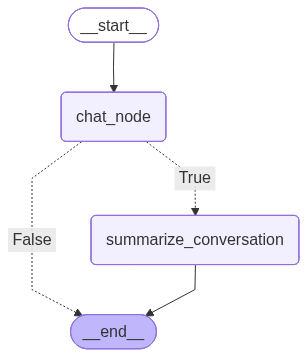

In [102]:
graph

In [122]:

CONFIG={'configurable':{'thread_id':"thread_1"}}

In [ ]:
def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=CONFIG)
    return out

In [118]:
#GIVE CURRENT STATE  VERSION OF STATE
def get_state():
    snap=graph.get_state(CONFIG)
    vals=snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])


In [120]:
run_turn('Quantum Physics')
get_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='c0e8881a-8644-48da-b796-a2f717f9f379')]


NameError: name 'CONFIG' is not defined